# Predictive Comparison: Logistic Regression vs Random Forest vs XGBoost

UK RMBS loan-level data. Secondary/contextual content around RQ1 - the interpretability-accuracy trade-off (Breiman's "two cultures"; Lessmann et al. 2015; Bucker et al. 2020), not a standalone research question (`decisions_log.md`, Part B.1). RQ1's inference result does not depend on anything in this notebook.

**Feature set** excludes `InterestRate_AtReference` (present in the inference model) - that feature's threshold was discovered via exploratory analysis on the full sample, so carrying it into a train/test-split comparison would leak test-set information into a derived feature (`decisions_log.md`, Part B.5c). All three models here get identical, leakage-free inputs: `Original_LTV`, `Interest_Rate` (raw, linear), `Loan_Term`, `Income_log`, and the `Property_Type`/`Purpose`/`Income_Verification` dummies.

**Class imbalance** handled via class-weighting (not SMOTE) for all three models - simpler to apply identically and defensibly across different algorithm types, avoids a second imbalance-handling justification stacked on an already extensively-documented pipeline. SMOTE was considered and deferred, not ruled out, if time allows revisiting.

## Setup

In [5]:
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_predict,
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    classification_report, confusion_matrix,
)


def youdens_j_threshold(y_true, y_pred_prob):
    """Threshold maximising Youden's J = TPR - FPR (Youden, 1950) - same
    quantity as the KS statistic used for cutoffs in credit scoring
    (Hand & Henley, 1997). Mirrors the threshold logic already used in
    the inference script for consistency across the two scripts."""
    fpr, tpr, thresh = roc_curve(y_true, y_pred_prob)
    return thresh[np.argmax(tpr - fpr)]


from google.colab import drive
drive.mount("/content/drive")

DATA_FOLDER = "/content/drive/MyDrive/Dissertation/data2"
RANDOM_STATE = 42


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# Okabe-Ito palette, continued from the cleaning and inference scripts
PALETTE = {
    "primary": "#0072B2",
    "highlight": "#D55E00",
    "secondary": "#009E73",
    "tertiary": "#E69F00",
    "neutral": "#3A3A3A",
}
plt.rcParams.update({
    "axes.edgecolor": PALETTE["neutral"],
    "axes.labelcolor": PALETTE["neutral"],
    "xtick.color": PALETTE["neutral"],
    "ytick.color": PALETTE["neutral"],
    "text.color": PALETTE["neutral"],
    "axes.grid": True,
    "grid.color": "#D9D9D9",
    "grid.linewidth": 0.5,
    "figure.dpi": 110,
})

FIGURE_COUNTER = {"n": 21}  # continues from the inference script, which
                            # ends at Figure 21 (the odds-ratio plot), not
                            # 18 - an earlier value of 18 collided with
                            # three figures already used there


def styled_figure(title, xlabel, ylabel):
    FIGURE_COUNTER["n"] += 1
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.set_title(f"Figure {FIGURE_COUNTER['n']}: {title}",
                 fontsize=11, fontweight="bold", color=PALETTE["neutral"], pad=12)
    ax.set_xlabel(xlabel, fontsize=9.5)
    ax.set_ylabel(ylabel, fontsize=9.5)
    return fig, ax


## Step 1: Load Data

In [7]:
# same reproducibility check as the other two scripts
df = pd.read_csv(f"{DATA_FOLDER}/cleaned_dissertation_data.csv", low_memory=False)
print(f"Loaded: {len(df):,} rows, {df.shape[1]} cols, "
      f"default rate = {df['default'].mean():.2%}")
print("Compare against the cleaning script's final printout "
      "(163,348 rows, 61 cols, 1.05%) before proceeding.")

# feature set - deliberately excludes InterestRate_AtReference (leakage,
# see intro cell); identical across all three models
predictors = [
    "Original_LTV", "Interest_Rate", "Loan_Term", "Income_log",
    "PropType_Flat", "PropType_Bungalow", "PropType_Terraced",
    "Purpose_Remortgage", "Purpose_DebtConsolidation", "Purpose_Renovation",
    "Purpose_RemortgageEquityRelease", "Purpose_Other", "IncVerif_Other",
]
X = df[predictors].astype(float)
y = df["default"].astype(int)


Loaded: 163,348 rows, 61 cols, default rate = 1.05%
Compare against the cleaning script's final printout (163,348 rows, 61 cols, 1.05%) before proceeding.


## Step 2: Train/Test Split and Class Weighting

80/20 stratified split - reserved for exactly this comparison since the inference model (RQ1) is fit on the full sample instead (`decisions_log.md`, Part B.2).

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train):,} rows, {y_train.sum():,} events "
      f"({y_train.mean():.2%})")
print(f"Test: {len(X_test):,} rows, {y_test.sum():,} events "
      f"({y_test.mean():.2%}) - held out untouched until final evaluation")

# Reproducibility check shared with smote_nc_comparison_script.ipynb. That
# script compares class-weighting against SMOTE-NC using figures loaded
# from this script's exported summary, which is only a valid comparison if
# both scripts evaluated on the same held-out rows. Identical split
# parameters should guarantee that, but "should" is not a check - hashing
# the test-set index makes it verifiable instead of assumed.
test_index_hash = hashlib.md5(
    ",".join(map(str, sorted(X_test.index))).encode()
).hexdigest()
print(f"\nTest-set index hash: {test_index_hash}")
print("This must match the hash printed by smote_nc_comparison_script.ipynb.")

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nClass weighting: scale_pos_weight (XGBoost) = {scale_pos_weight:.2f}; "
      f"'balanced' (sklearn) applies an equivalent inverse-frequency weight "
      f"for LR/RF.")

inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


Train: 130,678 rows, 1,377 events (1.05%)
Test: 32,670 rows, 344 events (1.05%) - held out untouched until final evaluation

Test-set index hash: e3895d473eed1bf075aca9aaba705456
This must match the hash printed by smote_nc_comparison_script.ipynb.

Class weighting: scale_pos_weight (XGBoost) = 93.90; 'balanced' (sklearn) applies an equivalent inverse-frequency weight for LR/RF.


## Step 3a: Tune Logistic Regression

Standardized inside a `Pipeline` - predictors have very different natural scales (`Loan_Term` up to ~600 vs 0/1 dummies), which caused `lbfgs` convergence failures at low regularization (high `C`) when unscaled. Standardizing is harmless for RF/XGBoost (scale-invariant, not applied there) and means LR's coefficients are already on a comparable scale for the Step 5 feature-importance comparison, with no post-hoc rescaling needed.

Tuned on the training set only (inner CV), scored on PR-AUC - more informative than ROC-AUC under this level of imbalance (Saito & Rehmsmeier, 2015, *PLOS ONE* 10(3), e0118432), consistent with the primary metric used throughout the inference script.

In [9]:
lr_grid = {"clf__C": [0.001, 0.01, 0.1, 1, 10, 100]}
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", solver="lbfgs")),
])
lr_search = GridSearchCV(
    lr_pipeline, lr_grid, cv=inner_cv, scoring="average_precision", n_jobs=-1,
)
lr_search.fit(X_train, y_train)
print(f"Best LR: C={lr_search.best_params_['clf__C']}, "
      f"CV PR-AUC={lr_search.best_score_:.4f}")


Best LR: C=0.1, CV PR-AUC=0.0220


## Step 3b: Tune Random Forest

`max_depth=None` (unconstrained) with `min_samples_leaf=1` measured at ~35s per fit on this data's 130,678 training rows against ~8s for a constrained configuration - genuinely expensive rather than a parallelism artefact, and low value for secondary/contextual content. Excluded from the grid rather than left in and hoped around.

`GridSearchCV` (exhaustive) rather than `RandomizedSearchCV`, applied consistently to all three models in this script and to the SMOTE-NC comparison, so no model competes on a fuller search than another. `n_jobs=-1` is set only at the search level, which parallelises across folds and candidates; the estimator itself is `n_jobs=1`. Setting both to `-1` causes nested parallelism that oversubscribes cores and slows the run - a contributing cause of an earlier 42-minute runtime on this step.

**Grid range.** An earlier version of this grid returned a best configuration sitting on two of its own edges (`max_depth` at the smallest value offered, `min_samples_leaf` at the largest). A boundary solution means the search never bracketed the optimum, so the reported performance is conditional on where the grid happened to stop rather than on where the model performs best. The grid is extended outward in both directions here, and the cell asserts explicitly whether the selected values are interior. This matters for the comparison's conclusion: if the ensembles are under-tuned, "logistic regression performs as well as the ensembles" is not a finding about the algorithms.


In [11]:
rf_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 10, 20],
    "min_samples_leaf": [5, 20, 50, 100],
}
rf_search = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1),
    rf_grid, cv=inner_cv, scoring="average_precision", n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF: {rf_search.best_params_}, CV PR-AUC={rf_search.best_score_:.4f}")


def report_grid_boundaries(search, grid, label):
    """Flag any tuned hyperparameter selected at the edge of its own grid.

    A boundary selection means the search stopped before the optimum was
    bracketed, so the result is conditional on the grid's range. Reported
    rather than silently accepted, since it directly qualifies any claim
    that one model outperforms another."""
    boundary = []
    for param, values in grid.items():
        chosen = search.best_params_[param]
        if len(values) > 1 and chosen in (min(values), max(values)):
            boundary.append(f"{param}={chosen} (grid {min(values)}-{max(values)})")
    if boundary:
        print(f"{label}: BOUNDARY selection on {', '.join(boundary)} - the "
              f"optimum is not bracketed and the grid should be widened "
              f"before this model's performance is compared against others.")
    else:
        print(f"{label}: all tuned hyperparameters selected in the interior "
              f"of their grids - the optimum is bracketed.")


report_grid_boundaries(rf_search, rf_grid, "Random Forest")


Best RF: {'max_depth': 10, 'min_samples_leaf': 100, 'n_estimators': 100}, CV PR-AUC=0.0234
Random Forest: BOUNDARY selection on n_estimators=100 (grid 100-200), min_samples_leaf=100 (grid 5-100) - the optimum is not bracketed and the grid should be widened before this model's performance is compared against others.


## Step 3c: Tune XGBoost

Exhaustive `GridSearchCV` over all 24 combinations, for the same reason given for the Random Forest: an earlier version used a bounded 10-draw random search here while the Random Forest received a full grid, which meant one model in a three-way comparison was tuned less thoroughly than another. Equal search effort across competing algorithms is a precondition for the comparison meaning anything, and applying that standard to two of three models is the same asymmetry, relocated. The same boundary check is applied.


In [14]:
xgb_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1, 0.3],
}
xgb_search = GridSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
                  eval_metric="logloss", n_jobs=1),
    xgb_grid, cv=inner_cv, scoring="average_precision", n_jobs=-1,
)
xgb_search.fit(X_train, y_train)
print(f"Best XGBoost: {xgb_search.best_params_}, "
      f"CV PR-AUC={xgb_search.best_score_:.4f}")
report_grid_boundaries(xgb_search, xgb_grid, "XGBoost")
report_grid_boundaries(lr_search, lr_grid, "Logistic Regression")

models = {
    "Logistic Regression": lr_search.best_estimator_,
    "Random Forest": rf_search.best_estimator_,
    "XGBoost": xgb_search.best_estimator_,
}


Best XGBoost: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}, CV PR-AUC=0.0237
XGBoost: BOUNDARY selection on n_estimators=100 (grid 100-200), max_depth=3 (grid 3-7) - the optimum is not bracketed and the grid should be widened before this model's performance is compared against others.
Logistic Regression: all tuned hyperparameters selected in the interior of their grids - the optimum is bracketed.


## Step 4: Test-Set Evaluation

Final, single evaluation on the held-out test set - touched exactly once, here, per model, using each model's tuned configuration.

In [15]:
results = {}
for name, model in models.items():
    test_pred = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, test_pred)
    pr_auc = average_precision_score(y_test, test_pred)
    results[name] = {"pred": test_pred, "roc_auc": roc_auc, "pr_auc": pr_auc}
    print(f"{name}: ROC-AUC={roc_auc:.4f}, PR-AUC={pr_auc:.4f} "
          f"(base rate={y_test.mean():.4f})")


Logistic Regression: ROC-AUC=0.7179, PR-AUC=0.0280 (base rate=0.0105)
Random Forest: ROC-AUC=0.7127, PR-AUC=0.0243 (base rate=0.0105)
XGBoost: ROC-AUC=0.7177, PR-AUC=0.0287 (base rate=0.0105)


In [16]:
# Are the three models actually distinguishable? Paired bootstrap on the
# test set. The point estimates below differ in the third decimal place,
# and with only 344 events in the test set that is well inside sampling
# noise - reporting one model as "best" on such a margin would overstate
# what the data supports. Resampling the test set with replacement and
# recomputing all three models' metrics on each resample gives the
# sampling distribution of the DIFFERENCES directly; the bootstrap is
# paired (the same resampled rows are used for every model) so it accounts
# for the models' predictions being highly correlated with one another.
rng = np.random.default_rng(RANDOM_STATE)
n_boot = 1000
model_names = list(results.keys())
boot_roc = {name: [] for name in model_names}
boot_pr = {name: [] for name in model_names}
y_test_arr = y_test.values

for _ in range(n_boot):
    idx = rng.integers(0, len(y_test_arr), len(y_test_arr))
    if y_test_arr[idx].sum() == 0:      # degenerate resample, no events
        continue
    for name in model_names:
        pred_b = results[name]["pred"][idx]
        boot_roc[name].append(roc_auc_score(y_test_arr[idx], pred_b))
        boot_pr[name].append(average_precision_score(y_test_arr[idx], pred_b))

print(f"Bootstrap 95% CIs ({n_boot} paired resamples of the test set):")
for name in model_names:
    lo_r, hi_r = np.percentile(boot_roc[name], [2.5, 97.5])
    lo_p, hi_p = np.percentile(boot_pr[name], [2.5, 97.5])
    print(f"  {name}: ROC-AUC {results[name]['roc_auc']:.4f} "
          f"[{lo_r:.4f}, {hi_r:.4f}], PR-AUC {results[name]['pr_auc']:.4f} "
          f"[{lo_p:.4f}, {hi_p:.4f}]")

print("\nPairwise differences (positive favours the first model):")
for i, a in enumerate(model_names):
    for b in model_names[i + 1:]:
        diff = np.array(boot_roc[a]) - np.array(boot_roc[b])
        lo, hi = np.percentile(diff, [2.5, 97.5])
        crosses = "includes 0" if lo <= 0 <= hi else "excludes 0"
        print(f"  ROC-AUC, {a} - {b}: "
              f"{results[a]['roc_auc'] - results[b]['roc_auc']:+.4f} "
              f"[{lo:+.4f}, {hi:+.4f}] - {crosses}")
print("A difference interval spanning zero means the two models are not "
      "distinguishable on this test set. Where that holds, the correct "
      "claim is that the added flexibility of the ensembles buys no "
      "detectable predictive advantage over logistic regression - which "
      "is a stronger and more defensible version of Breiman's (2001) "
      "point than declaring a winner on a third-decimal margin.")


Bootstrap 95% CIs (1000 paired resamples of the test set):
  Logistic Regression: ROC-AUC 0.7179 [0.6937, 0.7415], PR-AUC 0.0280 [0.0216, 0.0382]
  Random Forest: ROC-AUC 0.7127 [0.6901, 0.7358], PR-AUC 0.0243 [0.0202, 0.0317]
  XGBoost: ROC-AUC 0.7177 [0.6939, 0.7415], PR-AUC 0.0287 [0.0220, 0.0401]

Pairwise differences (positive favours the first model):
  ROC-AUC, Logistic Regression - Random Forest: +0.0052 [-0.0109, +0.0228] - includes 0
  ROC-AUC, Logistic Regression - XGBoost: +0.0002 [-0.0143, +0.0164] - includes 0
  ROC-AUC, Random Forest - XGBoost: -0.0050 [-0.0155, +0.0059] - includes 0
A difference interval spanning zero means the two models are not distinguishable on this test set. Where that holds, the correct claim is that the added flexibility of the ensembles buys no detectable predictive advantage over logistic regression - which is a stronger and more defensible version of Breiman's (2001) point than declaring a winner on a third-decimal margin.


### ROC and Precision-Recall Curves, All Three Models Overlaid

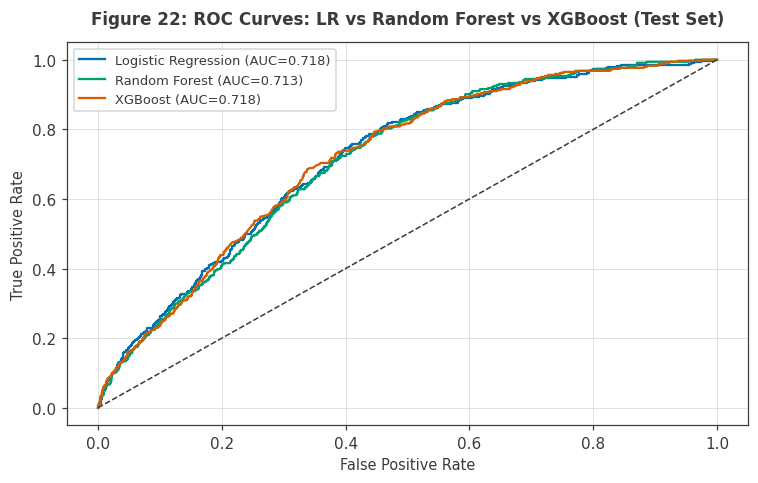

In [17]:
fig, ax = styled_figure("ROC Curves: LR vs Random Forest vs XGBoost (Test Set)",
                         "False Positive Rate", "True Positive Rate")
colors = {"Logistic Regression": PALETTE["primary"],
          "Random Forest": PALETTE["secondary"],
          "XGBoost": PALETTE["highlight"]}
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["pred"])
    ax.plot(fpr, tpr, color=colors[name], label=f"{name} (AUC={res['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], color=PALETTE["neutral"], linestyle="--", linewidth=1)
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.savefig(f"{DATA_FOLDER}/fig{FIGURE_COUNTER['n']}_roc_comparison.png", bbox_inches="tight")
plt.show()


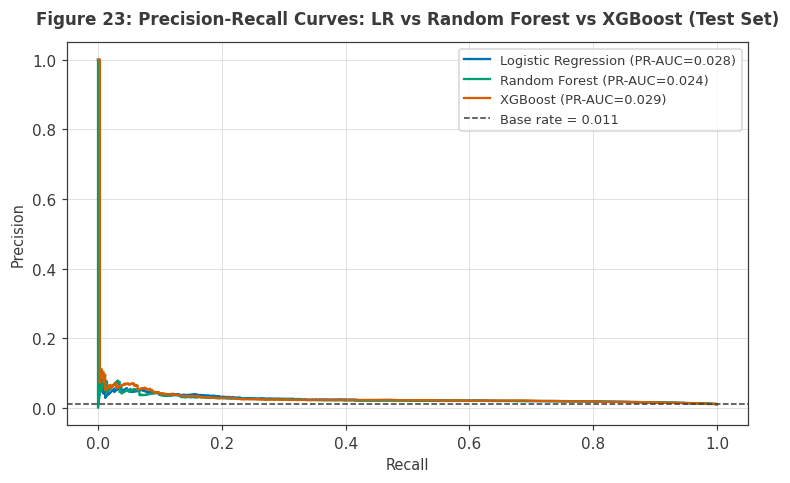

In [18]:
fig, ax = styled_figure("Precision-Recall Curves: LR vs Random Forest vs XGBoost (Test Set)",
                         "Recall", "Precision")
for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res["pred"])
    ax.plot(rec, prec, color=colors[name], label=f"{name} (PR-AUC={res['pr_auc']:.3f})")
ax.axhline(y_test.mean(), color=PALETTE["neutral"], linestyle="--", linewidth=1,
           label=f"Base rate = {y_test.mean():.3f}")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.savefig(f"{DATA_FOLDER}/fig{FIGURE_COUNTER['n']}_pr_comparison.png", bbox_inches="tight")
plt.show()


### Calibration Comparison

Calibration is whether a predicted probability means what it says: among loans given a predicted default probability of 2%, roughly 2% should default. It is a separate property from discrimination (ROC-AUC/PR-AUC), which only asks whether defaulting loans are ranked above non-defaulting ones, and the two can move in opposite directions - tree ensembles are documented as sometimes discriminating better while calibrating worse than logistic regression.

**An earlier version of this figure could not support the interpretation placed on it, and the fix matters.** All three models here are class-balanced (`class_weight="balanced"` for LR and RF, `scale_pos_weight` for XGBoost). Class balancing deliberately shifts the intercept so that the minority class is no longer predicted at its true base rate - so all three models are miscalibrated *by construction*, and comparing them against each other measures the effect of class weighting three times over rather than any difference between the algorithms. A fourth curve is therefore added: the same logistic regression fit with **no imbalance handling at all**, included purely as a calibration reference rather than as a fourth competitor. It is excluded from every discrimination comparison in this script.

That reference is what turns the figure into a test rather than an illustration, and it is the same test the SMOTE-NC script needs: van den Goorbergh et al.'s (2022) claim is that class-balancing worsens calibration, which cannot be evaluated by comparing two balanced approaches against each other. The unweighted model's calibration in the inference script (`baseline_LR_model4.ipynb`, Figure 18, Hosmer-Lemeshow p = 0.106) provides the corroborating full-sample view.

**Direction of the error, stated precisely.** The balanced models' curves sit *below* the diagonal: observed default rates are lower than predicted, so these models **over-predict** default risk. That is the expected consequence of up-weighting the minority class and is not a defect of any particular algorithm.


In [19]:
# Calibration reference model: logistic regression with NO imbalance
# handling, tuned on the same grid and the same inner CV as the weighted
# version. Its role is strictly as a calibration benchmark - it is not
# entered into any discrimination comparison, because doing so would
# quietly turn a three-model comparison into a four-model one and change
# what the script claims to test.
lr_unweighted_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, solver="lbfgs")),  # no class_weight
])
lr_unweighted_search = GridSearchCV(
    lr_unweighted_pipeline, lr_grid, cv=inner_cv,
    scoring="average_precision", n_jobs=-1,
)
lr_unweighted_search.fit(X_train, y_train)
calibration_reference_pred = lr_unweighted_search.best_estimator_.predict_proba(
    X_test)[:, 1]
print(f"Calibration reference (unweighted LR): "
      f"C={lr_unweighted_search.best_params_['clf__C']}, "
      f"mean predicted probability={calibration_reference_pred.mean():.4f} "
      f"vs observed test-set default rate={y_test.mean():.4f}")
print("A well-calibrated model's mean prediction should sit close to the "
      "observed base rate. Compare this against the class-weighted models "
      "below, whose mean predictions are inflated by construction.")


Calibration reference (unweighted LR): C=1, mean predicted probability=0.0106 vs observed test-set default rate=0.0105
A well-calibrated model's mean prediction should sit close to the observed base rate. Compare this against the class-weighted models below, whose mean predictions are inflated by construction.


In [20]:
# Per-algorithm calibration references. The unweighted LR alone cannot
# attribute the tree models' miscalibration: ensembles are documented as
# poorly calibrated even without class weighting, because averaging
# bounded leaf proportions compresses predictions away from 0 and 1. To
# isolate the effect of BALANCING - which is the specific claim in van den
# Goorbergh et al. (2022) - each algorithm needs its own balanced vs
# unbalanced contrast, not a comparison against a different algorithm.
#
# Tuned hyperparameters are held fixed at the weighted models' values
# rather than retuned. That is deliberate: retuning would let a tuning
# difference confound the weighting difference, and the weighting is the
# only factor this comparison is meant to vary.
rf_reference = RandomForestClassifier(
    **rf_search.best_params_, random_state=RANDOM_STATE, n_jobs=-1
).fit(X_train, y_train)
xgb_reference = XGBClassifier(
    **xgb_search.best_params_, random_state=RANDOM_STATE,
    eval_metric="logloss", n_jobs=-1
).fit(X_train, y_train)

calibration_references = {
    "LR, unweighted (reference)": calibration_reference_pred,
    "RF, unweighted (reference)": rf_reference.predict_proba(X_test)[:, 1],
    "XGBoost, unweighted (reference)": xgb_reference.predict_proba(X_test)[:, 1],
}
for name, pred in calibration_references.items():
    print(f"{name}: mean predicted probability={pred.mean():.4f} "
          f"(observed base rate={y_test.mean():.4f})")

LR, unweighted (reference): mean predicted probability=0.0106 (observed base rate=0.0105)
RF, unweighted (reference): mean predicted probability=0.0105 (observed base rate=0.0105)
XGBoost, unweighted (reference): mean predicted probability=0.0106 (observed base rate=0.0105)


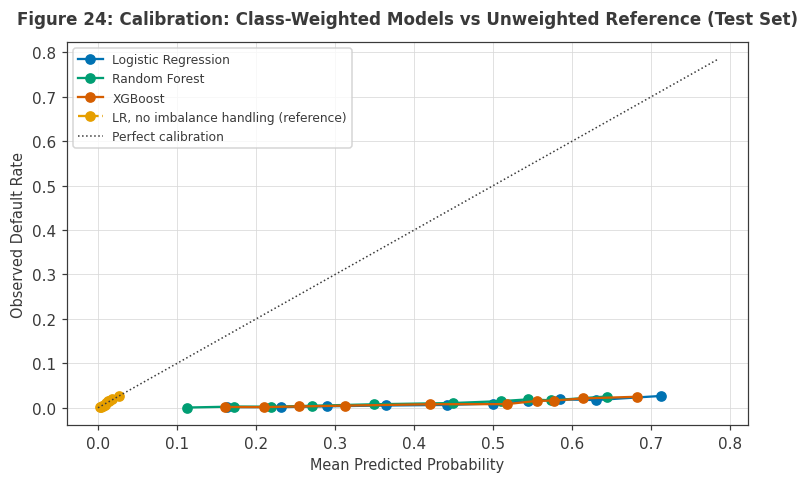

Observed test-set default rate: 0.0105
Mean predicted probability by model (a calibrated model's figure should sit near the observed rate):
  Logistic Regression: 0.4461 (42.4x the base rate, over-predicts default risk)
  Random Forest: 0.3845 (36.5x the base rate, over-predicts default risk)
  XGBoost: 0.4301 (40.8x the base rate, over-predicts default risk)
  LR, no imbalance handling (reference): 0.0106 (1.0x the base rate, over-predicts default risk)
The three class-balanced models sit far above the base rate and their curves fall below the diagonal - they over-predict risk, as class weighting is designed to make them do. The unweighted reference shows this is an artefact of the imbalance handling, not a property of any one algorithm, which is the comparison van den Goorbergh et al. (2022) actually concerns.


In [21]:
fig, ax = styled_figure(
    "Calibration: Class-Weighted Models vs Unweighted Reference (Test Set)",
    "Mean Predicted Probability", "Observed Default Rate"
)
calibration_series = dict(results)
calibration_series["LR, no imbalance handling (reference)"] = {
    "pred": calibration_reference_pred}
calib_colors = dict(colors)
calib_colors["LR, no imbalance handling (reference)"] = PALETTE["tertiary"]

max_val = 0
mean_pred_summary = {}
for name, res in calibration_series.items():
    calib_df = pd.DataFrame({"pred": res["pred"], "obs": y_test.values})
    calib_df["decile"] = pd.qcut(calib_df["pred"], q=10, duplicates="drop")
    calib = calib_df.groupby("decile", observed=True).agg(
        mean_pred=("pred", "mean"), mean_obs=("obs", "mean")
    )
    max_val = max(max_val, calib["mean_pred"].max(), calib["mean_obs"].max())
    mean_pred_summary[name] = res["pred"].mean()
    style = "--" if "reference" in name else "-"
    ax.plot(calib["mean_pred"], calib["mean_obs"], marker="o",
            color=calib_colors[name], linestyle=style, label=name)
ax.plot([0, max_val * 1.1], [0, max_val * 1.1], color=PALETTE["neutral"],
        linestyle=":", linewidth=1, label="Perfect calibration")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{DATA_FOLDER}/fig{FIGURE_COUNTER['n']}_calibration_comparison.png",
            bbox_inches="tight")
plt.show()

print(f"Observed test-set default rate: {y_test.mean():.4f}")
print("Mean predicted probability by model (a calibrated model's figure "
      "should sit near the observed rate):")
for name, mean_pred in mean_pred_summary.items():
    ratio = mean_pred / y_test.mean()
    direction = "over-predicts" if ratio > 1 else "under-predicts"
    print(f"  {name}: {mean_pred:.4f} ({ratio:.1f}x the base rate, "
          f"{direction} default risk)")
print("The three class-balanced models sit far above the base rate and "
      "their curves fall below the diagonal - they over-predict risk, as "
      "class weighting is designed to make them do. The unweighted "
      "reference shows this is an artefact of the imbalance handling, not "
      "a property of any one algorithm, which is the comparison van den "
      "Goorbergh et al. (2022) actually concerns.")


In [25]:
# Calibration intercept, slope and Brier skill score.
#
# Calibration intercept: fitted with the model's own logit as a fixed
# offset and the slope constrained to 1, so it measures systematic
# over- or under-prediction alone. 0 is perfect; positive means the
# model under-predicts, negative means it over-predicts.
# Calibration slope: regressing the outcome on the model's logit. 1 is
# perfect; below 1 means predictions are too extreme (over-fitted risk
# spread), above 1 too compressed.
# Both are the measures van den Goorbergh et al. (2022) use, and both are
# reported here in preference to a raw Brier score, which at a ~1% event
# rate is dominated by the base-rate term and mixes calibration with
# discrimination rather than isolating calibration.
import statsmodels.api as sm
from sklearn.metrics import brier_score_loss

def calibration_metrics(y_true, p, eps=1e-12):
    p = np.clip(np.asarray(p, dtype=float), eps, 1 - eps)
    logit_p = np.log(p / (1 - p))
    intercept = sm.Logit(y_true, np.ones(len(p)),
                         offset=logit_p).fit(disp=0).params[0]
    slope = sm.Logit(y_true, sm.add_constant(logit_p)).fit(disp=0).params[1]
    brier = brier_score_loss(y_true, p)
    base = float(np.mean(y_true))
    skill = 1 - brier / (base * (1 - base))   # vs predicting the base rate
    return intercept, slope, brier, skill


calibration_panel = {name: res["pred"] for name, res in results.items()}
calibration_panel.update(calibration_references)

rows = []
for name, pred in calibration_panel.items():
    intercept, slope, brier, skill = calibration_metrics(y_test.values, pred)
    rows.append({"model": name, "calibration_intercept": round(intercept, 4),
                 "calibration_slope": round(slope, 4),
                 "Brier": round(brier, 6),
                 "Brier_skill_vs_base_rate": round(skill, 4)})
calibration_table = pd.DataFrame(rows).set_index("model")
print(calibration_table.to_string())
calibration_table.to_csv(f"{DATA_FOLDER}/calibration_metrics.csv")

print("\\nRead the intercept as the calibration test and the Brier skill "
      "score as a reminder of scale. A large negative intercept means "
      "systematic over-prediction; compare each class-weighted model "
      "against its OWN unweighted reference, not against a different "
      "algorithm, since that within-algorithm contrast is the only one "
      "that isolates the effect of balancing. Brier itself barely moves "
      "across models at this event rate, which is why it is reported as a "
      "skill score against the base rate rather than raw.")

                                 calibration_intercept  calibration_slope     Brier  Brier_skill_vs_base_rate
model                                                                                                        
Logistic Regression                            -4.5523             1.1832  0.227269                  -20.8136
Random Forest                                  -4.2854             1.1427  0.178796                  -16.1611
XGBoost                                        -4.4824             1.2139  0.214913                  -19.6277
LR, unweighted (reference)                     -0.0031             1.2189  0.010344                    0.0072
RF, unweighted (reference)                     -0.0015             1.2485  0.010344                    0.0071
XGBoost, unweighted (reference)                -0.0041             1.2054  0.010344                    0.0072
\nRead the intercept as the calibration test and the Brier skill score as a reminder of scale. A large negative intercep

### Classification Reports (Precision/Recall/F1 per Class)

Same tabular format `sklearn`'s `classification_report` produces. Threshold selection stays leakage-safe: Youden's J / KS threshold (Youden, 1950; Hand & Henley, 1997) is derived from each model's **training-set out-of-fold predictions** (`cross_val_predict`, same `inner_cv` used for hyperparameter tuning), never from the test set directly - consistent with the discipline already used in the inference script.

In [26]:
for name, model in models.items():
    oof_pred = cross_val_predict(
        model, X_train, y_train, cv=inner_cv, method="predict_proba", n_jobs=-1
    )[:, 1]
    threshold = youdens_j_threshold(y_train, oof_pred)
    test_pred_class = (results[name]["pred"] >= threshold).astype(int)
    print(f"\n{name} (threshold={threshold:.4f}):")
    print(classification_report(y_test, test_pred_class,
                                 target_names=["No Default", "Default"], digits=4))
    cm = confusion_matrix(y_test, test_pred_class, labels=[0, 1])
    cm_df = pd.DataFrame(
        cm, index=["Actual: No Default", "Actual: Default"],
        columns=["Predicted: No Default", "Predicted: Default"]
    )
    print(f"Confusion matrix ({name}, test set, n={len(y_test):,}):")
    print(cm_df)



Logistic Regression (threshold=0.4658):
              precision    recall  f1-score   support

  No Default     0.9965    0.4898    0.6568     32326
     Default     0.0172    0.8372    0.0336       344

    accuracy                         0.4934     32670
   macro avg     0.5068    0.6635    0.3452     32670
weighted avg     0.9862    0.4934    0.6502     32670

Confusion matrix (Logistic Regression, test set, n=32,670):
                    Predicted: No Default  Predicted: Default
Actual: No Default                  15833               16493
Actual: Default                        56                 288

Random Forest (threshold=0.3981):
              precision    recall  f1-score   support

  No Default     0.9964    0.4997    0.6656     32326
     Default     0.0173    0.8285    0.0339       344

    accuracy                         0.5032     32670
   macro avg     0.5068    0.6641    0.3498     32670
weighted avg     0.9861    0.5032    0.6590     32670

Confusion matrix (Random

## Step 5: Feature Importance Comparison

LR's coefficients come from the `StandardScaler` pipeline, so they are already on a comparable scale to each other - raw, unscaled coefficients would not be comparable across predictors with very different natural ranges (`Original_LTV` 0-100 against a 0/1 dummy). **Rankings, not raw magnitudes, are what compare across model types**: the three importance metrics are on different scales by construction.

**A known measurement artefact competes with the substantive reading, and is tested rather than caveated away.** The Random Forest's Gini (mean decrease in impurity) importance is biased toward continuous and high-cardinality predictors, because such variables offer many more candidate split points and can therefore reduce impurity by chance more often than a binary dummy can (Strobl, Boulesteix, Zeileis and Hothorn, 2007). That bias predicts exactly the pattern seen below - continuous predictors dominating, every dummy near zero - independently of whether the dummies carry real signal. So a divergence between logistic regression's standardised coefficients and the tree models' importances cannot be attributed to trees capturing non-linear structure until the artefact is ruled out.

Permutation importance, computed immediately below the importance table, is the standard remedy: it measures the drop in held-out predictive performance when a single predictor's values are shuffled, which is defined identically for a continuous predictor and a dummy and so is not subject to the split-point bias. Where the two rankings agree, the Gini reading stands; where they disagree, permutation importance is the one to report.


In [27]:
lr_coefs = models["Logistic Regression"].named_steps["clf"].coef_[0]
lr_importance = pd.Series(np.abs(lr_coefs), index=predictors).sort_values(ascending=False)

rf_importance = pd.Series(
    models["Random Forest"].feature_importances_, index=predictors
).sort_values(ascending=False)

xgb_importance = pd.Series(
    models["XGBoost"].feature_importances_, index=predictors
).sort_values(ascending=False)

importance_table = pd.DataFrame({
    "LR (|std coef|)": lr_importance,
    "RF (Gini importance)": rf_importance,
    "XGBoost (gain-based)": xgb_importance,
}).round(4)
print(importance_table)

top3_lr = set(lr_importance.head(3).index)
top3_rf = set(rf_importance.head(3).index)
top3_xgb = set(xgb_importance.head(3).index)
print(f"\nTop-3 agreement: LR&RF={len(top3_lr & top3_rf)}/3, "
      f"LR&XGBoost={len(top3_lr & top3_xgb)}/3, "
      f"RF&XGBoost={len(top3_rf & top3_xgb)}/3")


                                 LR (|std coef|)  RF (Gini importance)  \
IncVerif_Other                            0.0312                0.0165   
Income_log                                0.0640                0.1489   
Interest_Rate                             0.5783                0.3668   
Loan_Term                                 0.2241                0.1566   
Original_LTV                              0.2691                0.1920   
PropType_Bungalow                         0.0972                0.0090   
PropType_Flat                             0.0574                0.0129   
PropType_Terraced                         0.0079                0.0119   
Purpose_DebtConsolidation                 0.2977                0.0539   
Purpose_Other                             0.0593                0.0011   
Purpose_Remortgage                        0.2072                0.0173   
Purpose_RemortgageEquityRelease           0.0923                0.0054   
Purpose_Renovation                    

In [28]:
# Permutation importance for the Random Forest, as the unbiased complement
# to Gini importance (Strobl et al., 2007 - see the note above).
# Computed on the held-out TEST set and scored on average precision
# (PR-AUC), matching the metric used for tuning and for the headline
# comparison, so importance is measured against the quantity the model was
# actually selected on rather than against accuracy, which is
# uninformative at a 1% event rate.
perm = permutation_importance(
    models["Random Forest"], X_test, y_test,
    scoring="average_precision", n_repeats=10,
    random_state=RANDOM_STATE, n_jobs=-1,
)
perm_importance = pd.Series(perm.importances_mean, index=predictors)
perm_sd = pd.Series(perm.importances_std, index=predictors)

perm_table = pd.DataFrame({
    "RF (Gini importance)": rf_importance,
    "RF Gini rank": rf_importance.rank(ascending=False).astype(int),
    "RF (permutation, PR-AUC drop)": perm_importance.round(5),
    "permutation SD": perm_sd.round(5),
    "RF permutation rank": perm_importance.rank(ascending=False).astype(int),
}).sort_values("RF permutation rank")
print(perm_table.to_string())

rank_shift = (perm_table["RF Gini rank"]
              - perm_table["RF permutation rank"]).abs()
print(f"\nLargest rank movement between the two importance measures: "
      f"{rank_shift.max()} places ({rank_shift.idxmax()}).")
print("Where the two rankings agree, the Gini reading is safe to report. "
      "Where they disagree, the permutation ranking is the one to quote, "
      "since Gini importance is biased toward predictors offering more "
      "candidate split points and cannot distinguish that artefact from "
      "genuine signal. Permutation values are small in absolute terms "
      "because PR-AUC itself is bounded near the base rate at this event "
      "rate - the ordering, not the magnitude, is the interpretable part, "
      "and any value within about two SDs of zero should be read as "
      "indistinguishable from no contribution.")


                                 RF (Gini importance)  RF Gini rank  RF (permutation, PR-AUC drop)  permutation SD  RF permutation rank
Interest_Rate                                0.366807             1                        0.00727         0.00079                    1
Loan_Term                                    0.156552             3                        0.00467         0.00086                    2
Purpose_DebtConsolidation                    0.053873             5                        0.00379         0.00050                    3
PropType_Flat                                0.012904             8                        0.00120         0.00053                    4
Purpose_Renovation                           0.007605            11                        0.00059         0.00013                    5
Purpose_Remortgage                           0.017297             6                        0.00056         0.00030                    6
Original_LTV                                 0.1

### Feature Importance Chart

Three side-by-side subplots, not one grouped chart - the three importance metrics are on different scales by construction (per the table above), so a single shared-axis grouped bar would misleadingly imply magnitude comparability that doesn't exist. Each subplot sorted by that model's own ranking.

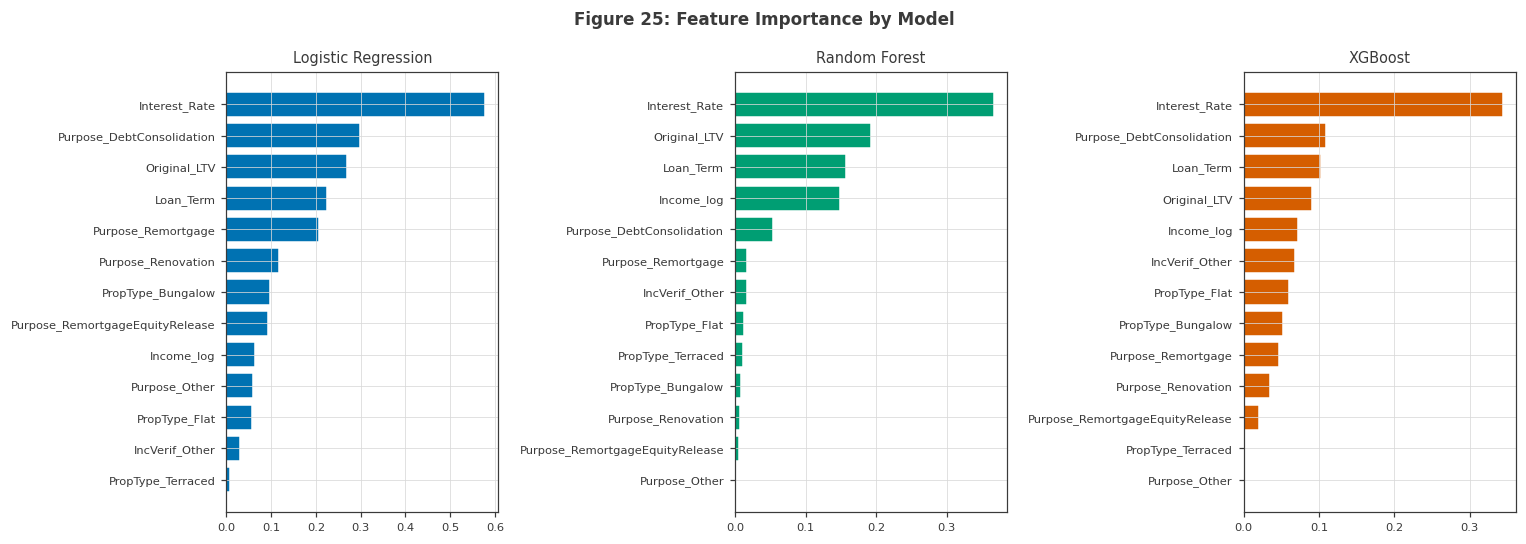

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle(f"Figure {FIGURE_COUNTER['n'] + 1}: Feature Importance by Model",
             fontsize=11, fontweight="bold", color=PALETTE["neutral"])
FIGURE_COUNTER["n"] += 1
importances = {
    "Logistic Regression": (lr_importance, PALETTE["primary"]),
    "Random Forest": (rf_importance, PALETTE["secondary"]),
    "XGBoost": (xgb_importance, PALETTE["highlight"]),
}
for ax, (name, (imp, color)) in zip(axes, importances.items()):
    imp_sorted = imp.sort_values()
    ax.barh(imp_sorted.index, imp_sorted.values, color=color, edgecolor="white")
    ax.set_title(name, fontsize=9.5, color=PALETTE["neutral"])
    ax.tick_params(axis="y", labelsize=7.5)
    ax.tick_params(axis="x", labelsize=7.5)
plt.tight_layout()
plt.savefig(f"{DATA_FOLDER}/fig{FIGURE_COUNTER['n']}_feature_importance.png",
            bbox_inches="tight")
plt.show()


## Export Result Tables

In [30]:
comparison_summary = pd.DataFrame({
    name: {"ROC-AUC": res["roc_auc"], "PR-AUC": res["pr_auc"]}
    for name, res in results.items()
}).T
comparison_summary.round(4).to_csv(f"{DATA_FOLDER}/model_comparison_summary.csv")
importance_table.to_csv(f"{DATA_FOLDER}/feature_importance_comparison.csv")
print(f"Saved comparison summary and feature importance tables to {DATA_FOLDER}/")
perm_table.to_csv(f"{DATA_FOLDER}/rf_permutation_importance.csv")
print(f"Saved permutation-importance table to {DATA_FOLDER}/"
      f"rf_permutation_importance.csv")


Saved comparison summary and feature importance tables to /content/drive/MyDrive/Dissertation/data2/
Saved permutation-importance table to /content/drive/MyDrive/Dissertation/data2/rf_permutation_importance.csv
